In [1]:
import wandb
import pandas as pd
import numpy as np
import json
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(path="harvardml/opt-olmo")

In [5]:
optimizers = ['adamw', 'stableshampoo', 'stablershampoo'] # 
display_names = ['Adam', 'Stable Shampoo', 'Stabler Shampoo'] # 
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [6]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 25000
groups = ["sooptimizers-150-1", "sooptimizers-150-2", "sooptimizers-150-3"]
plot_key = "learning_rate"
display_key = "Learning Rate"

results = {}

for run in runs:
    if run.group in groups:
    
        run_dict = {}
        run_dict["id"] = run.id
        if run.group in ["optimizers-1", "optimizers-2", "sophia-5", "optimizers-sgd-1"]:
            run_dict["group"] = "optimizers-150-1"
        else:
            run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict[plot_key] = run.config["optimizer"][plot_key]
        
        if run.config["optimizer"]["name"] not in name_map:
            continue 
        
        if run.summary['_step'] < 25000:
            continue
        
        if run.config["optimizer"]["precondition_frequency"] > 1:
            key = name_map[run.config["optimizer"]["name"]]+' freq='+str(run.config["optimizer"]["precondition_frequency"])
        else:
            key = name_map[run.config["optimizer"]["name"]]
        if key not in results:
            results[key] = {}
        if "eval/c4_val/CrossEntropyLoss" in run.summary:
            results[key][run_dict[plot_key]] = run.summary["eval/c4_val/CrossEntropyLoss"]


In [7]:
results

{'Stabler Shampoo freq=100': {0.0001: 3.066021680831909,
  0.01: 3.03926420211792,
  0.00316: 3.026477575302124,
  0.001: 3.0344467163085938,
  0.000316: 3.040773391723633},
 'Stable Shampoo freq=100': {0.1: 3.029463052749634,
  0.001: 3.047179698944092,
  0.01: 3.0375709533691406,
  0.00316: 3.0366594791412354,
  0.000316: 3.1019036769866943,
  0.0316: 3.0302910804748535},
 'Stabler Shampoo freq=10': {0.01: 3.0326907634735107,
  0.00316: 3.0255441665649414,
  0.001: 3.0323026180267334,
  0.0001: 3.094421148300171,
  0.000316: 3.0569326877593994},
 'Stable Shampoo freq=10': {0.0316: 3.02886700630188,
  0.01: 3.0219225883483887,
  0.00316: 3.029740810394287,
  0.001: 3.043949604034424,
  0.000316: 3.111336469650269},
 'Adam': {0.01: 3.0693159103393555,
  0.0316: 3.1014175415039062,
  0.000316: 3.1512513160705566,
  0.001: 3.0733227729797363,
  0.00316: 3.055521011352539}}

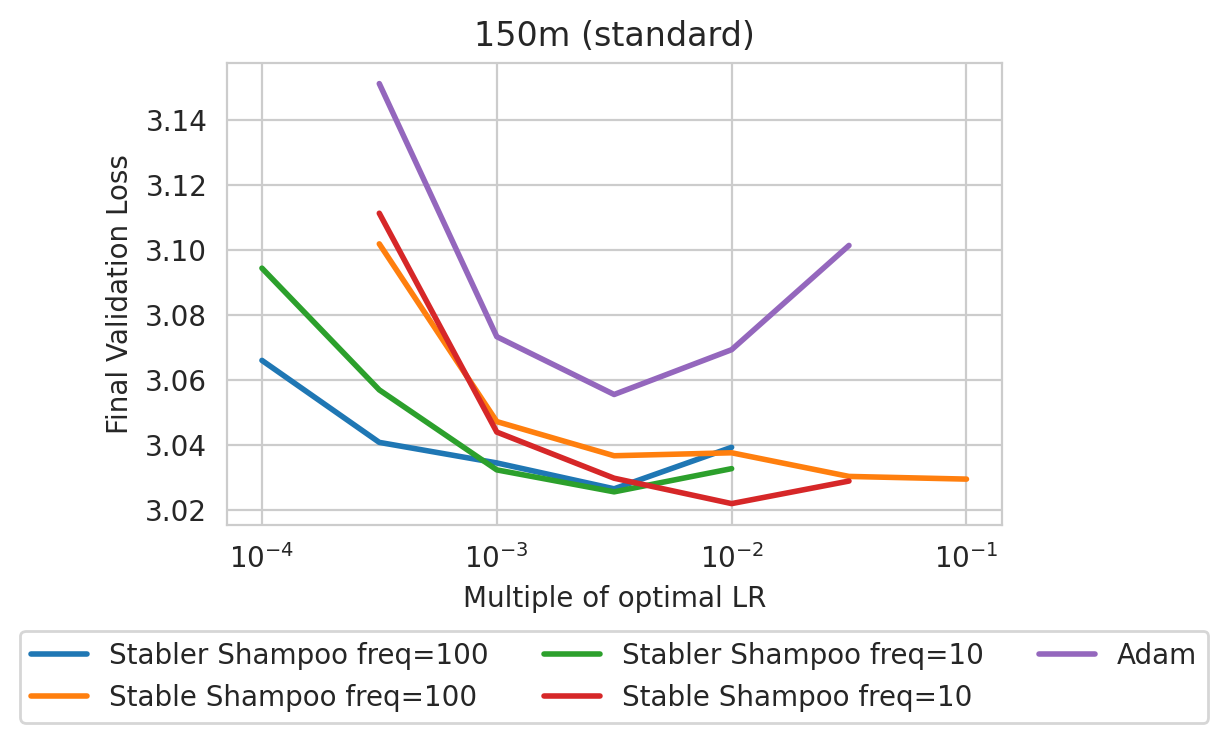

In [8]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

for key in results:
    
    # x = np.sort(list(results[key].keys()))
    # y = [results[key][i] for i in x]
    
    x = np.array(list(results[key].keys()))
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = np.array([results[key][i] for i in x])
    
    plt.plot(
        x,
        y, 
        label=key,
        linewidth=2)

plt.xscale("log")
# plt.xlim(3.2e-2, 1.5e2)
# plt.ylim(3.05, 3.4)
plt.xlabel("Multiple of optimal LR")
plt.ylabel("Final Validation Loss")
plt.title("150m (standard)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))
plt.show()

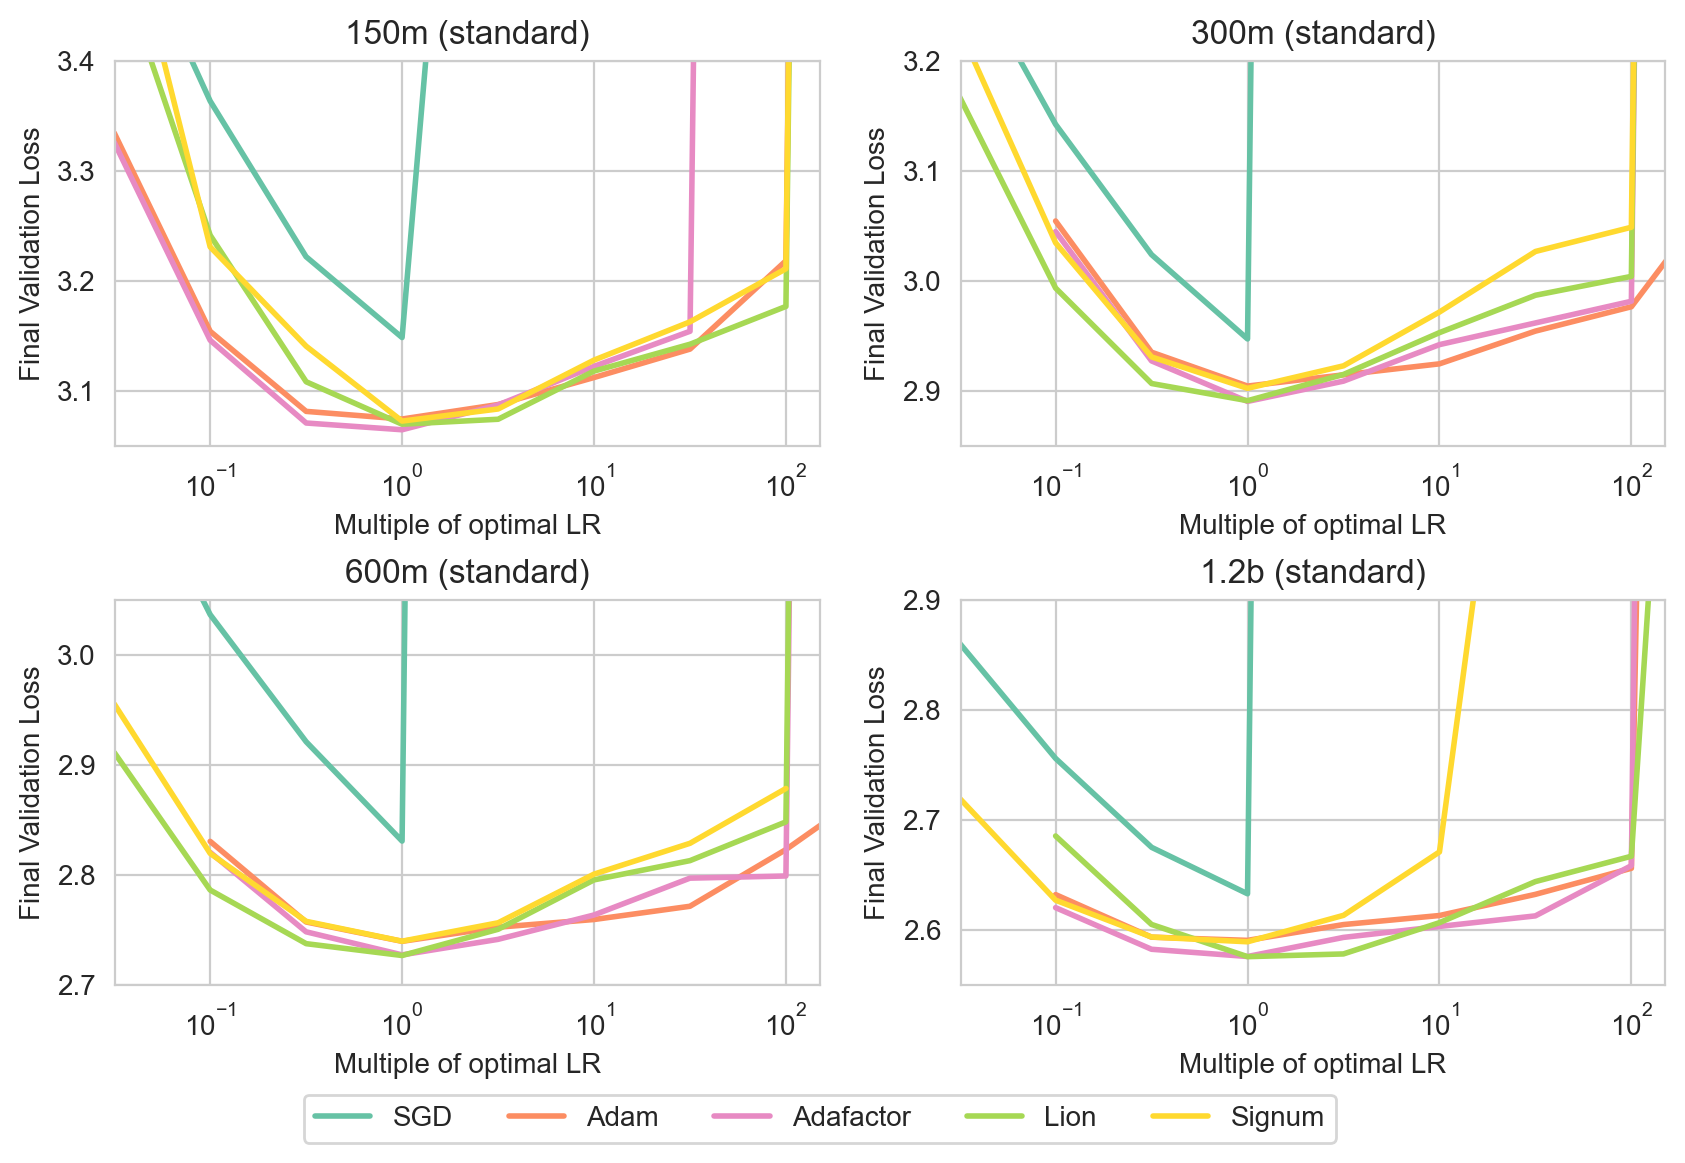

In [24]:
sns.set_style("whitegrid")
#plt.figure(figsize=(15, 3), dpi=200)  # Larger figure size
fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=200)

axs = axs.flatten()

# adjust vertical space
plt.subplots_adjust(hspace=0.4)

for i, group in enumerate(["optimizers-150-1", "optimizers-300-1", "optimizers-600-1", "optimizers-1b-1"]):

    ax = axs[i]
    group_df = df[df["group"] == group]
    best_lrs = group_lrs[group]
    
    adam_lr = best_lrs["adamw"]
    multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

    for optimizer in optimizers:
        if optimizer in ["sophiag", "novagradw_ours"]:
            continue
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by="learning_rate")
            # take minimal value for each learning rate
            optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
            ax.plot(
                multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
                optimizer_df["val_loss"], 
                label=name_map[optimizer],
                linewidth=2,
                color=color_map[optimizer],
                # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
            )

    ax.set_xscale("log")
    ax.set_xlim(3.2e-2, 1.5e2)
    if i == 0:
        ax.set_ylim(3.05, 3.4)
    elif i == 1:
        ax.set_ylim(2.85, 3.2)
    elif i == 2:
        ax.set_ylim(2.7, 3.05)
    elif i == 3:
        ax.set_ylim(2.55, 2.9)
    ax.set_xlabel("Multiple of optimal LR")
    ax.set_ylabel("Final Validation Loss")
    if i != 3:
        ax.set_title(f"{group.split('-')[1]}m (standard)")
    else:
        ax.set_title(f"1.2b (standard)")


axs[2].legend(loc='upper center', bbox_to_anchor=(1.0, -0.25), fancybox=True, shadow=False, ncol=len(optimizers))

plt.savefig('../figures/lrs_all_2.png', bbox_inches='tight')
plt.show()

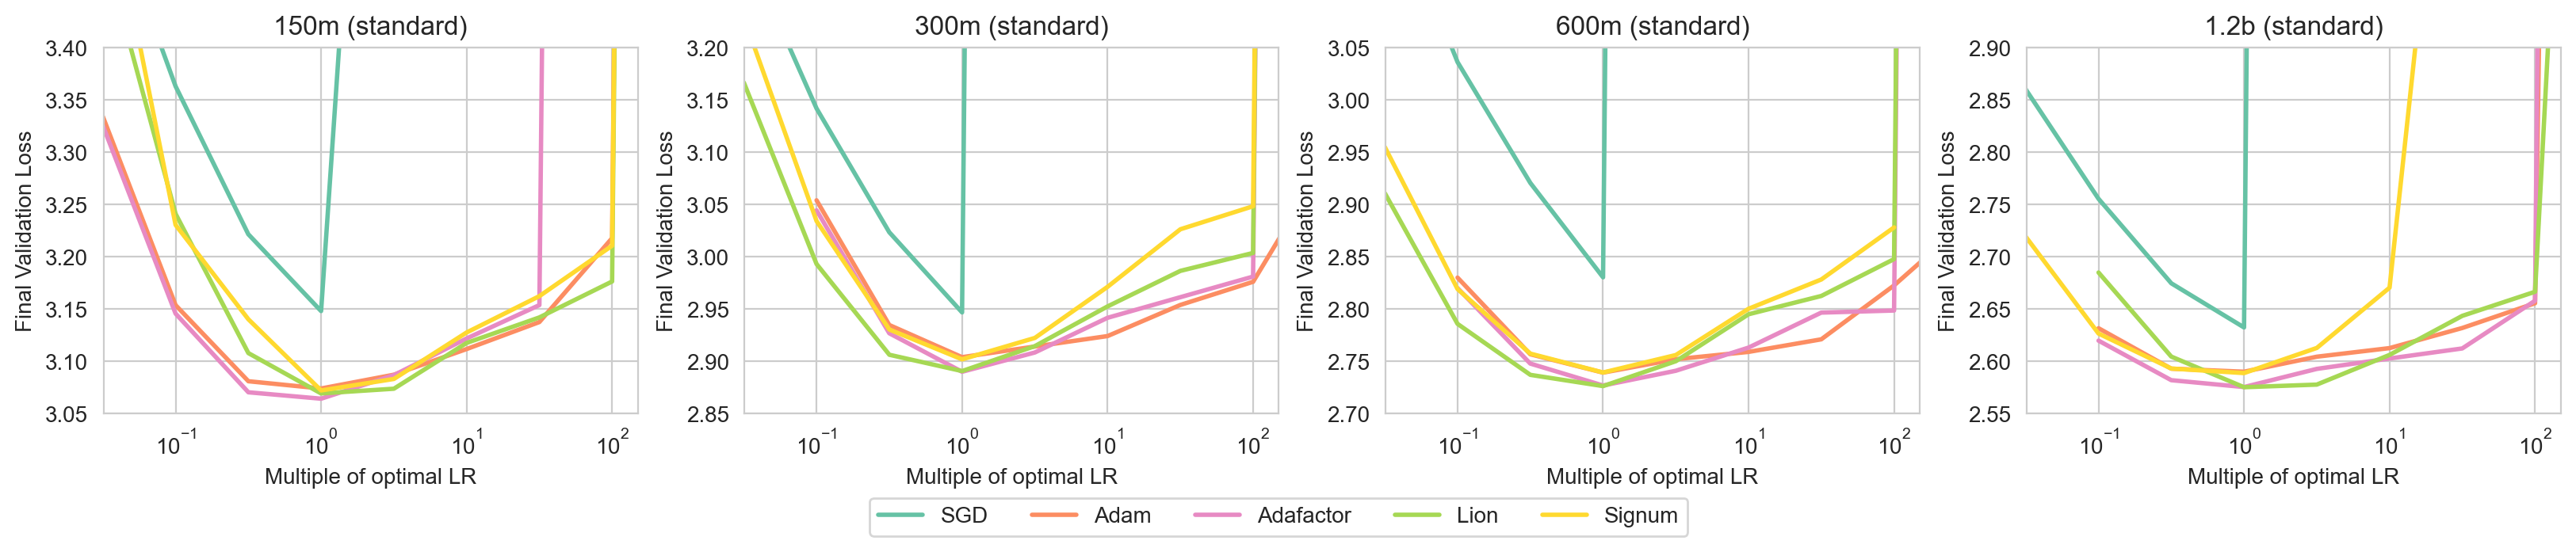

In [23]:
sns.set_style("whitegrid")
#plt.figure(figsize=(15, 3), dpi=200)  # Larger figure size
fig, axs = plt.subplots(1, 4, figsize=(20, 3), dpi=200)

axs = axs.flatten()

for i, group in enumerate(["optimizers-150-1", "optimizers-300-1", "optimizers-600-1", "optimizers-1b-1"]):

    ax = axs[i]
    group_df = df[df["group"] == group]
    best_lrs = group_lrs[group]
    
    adam_lr = best_lrs["adamw"]
    multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

    for optimizer in optimizers:
        if optimizer in ["sophiag", "novagradw_ours"]:
            continue
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by="learning_rate")
            # take minimal value for each learning rate
            optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
            ax.plot(
                multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
                optimizer_df["val_loss"], 
                label=name_map[optimizer],
                linewidth=2,
                color=color_map[optimizer],
                # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
            )

    ax.set_xscale("log")
    ax.set_xlim(3.2e-2, 1.5e2)
    if i == 0:
        ax.set_ylim(3.05, 3.4)
    elif i == 1:
        ax.set_ylim(2.85, 3.2)
    elif i == 2:
        ax.set_ylim(2.7, 3.05)
    elif i == 3:
        ax.set_ylim(2.55, 2.9)
    ax.set_xlabel("Multiple of optimal LR")
    ax.set_ylabel("Final Validation Loss")
    if i != 3:
        ax.set_title(f"{group.split('-')[1]}m (standard)")
    else:
        ax.set_title(f"1.2b (standard)")


axs[1].legend(loc='upper center', bbox_to_anchor=(1.0, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))

plt.savefig('../figures/lrs_all_1.png', bbox_inches='tight')
plt.show()